In [1]:
# =====================================================================================
# IMPORTS
# =====================================================================================
import os
import sys
import subprocess
import logging
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional, Union
from dataclasses import dataclass, field
from datetime import datetime
from collections import Counter
import gc

# --- Core Libraries ---
import pandas as pd
import numpy as np
from PIL import Image
import cv2

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- PyTorch and Deep Learning ---
import torch
import torch.nn as nn
import timm # PyTorch Image Models
from torch.utils.data import Dataset, DataLoader

# --- Sklearn ---
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# --- Utilities ---
from tqdm.auto import tqdm
import psutil

# =====================================================================================
# INITIAL CONFIGURATION
# =====================================================================================
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# =====================================================================================
# CONFIGURATION DATACLASS
# =====================================================================================
@dataclass
class MIDASConfig:
    """Configuration class for the MIDAS system."""
    project_name: str = "MIDAS-V1"
    seed: int = 42
    
    # --- Paths ---
    # Using Path objects for OS-agnostic path handling
    data_dir: Path = Path("data")
    models_dir: Path = Path("models")
    results_dir: Path = Path("results")
    logs_dir: Path = Path("logs")
    
    # --- Dataset Specific Paths ---
    ham10000_images: Path = data_dir / "ham10000/images"
    ham10000_metadata: Path = data_dir / "ham10000/metadata/HAM10000_metadata.csv"
    pad_ufes20_images: Path = data_dir / "pad_ufes20/images"
    # CORRECTED FILENAME as per your instruction
    pad_ufes20_metadata: Path = data_dir / "pad_ufes20/metadata/metadata.csv"

    # --- Class Definitions ---
    num_classes: int = 7
    # Class names for HAM10000
    class_names: List[str] = field(default_factory=lambda: ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC'])
    class_name_map: Dict[str, str] = field(default_factory=lambda: {
        'akiec': 'Actinic Keratoses',
        'bcc': 'Basal Cell Carcinoma',
        'bkl': 'Benign Keratosis',
        'df': 'Dermatofibroma',
        'mel': 'Melanoma',
        'nv': 'Nevus',
        'vasc': 'Vascular Lesions'
    })

    def __post_init__(self):
        """Create directories if they don't exist after initialization."""
        self.models_dir.mkdir(parents=True, exist_ok=True)
        (self.models_dir / "checkpoints").mkdir(exist_ok=True)
        (self.models_dir / "trained").mkdir(exist_ok=True)
        self.results_dir.mkdir(parents=True, exist_ok=True)
        (self.results_dir / "plots").mkdir(exist_ok=True)
        (self.results_dir / "metrics").mkdir(exist_ok=True)
        self.logs_dir.mkdir(parents=True, exist_ok=True)

config = MIDASConfig()

# =====================================================================================
# LOGGING AND ENVIRONMENT SETUP
# =====================================================================================
def setup_logging(logs_dir: Path, project_name: str) -> logging.Logger:
    """Configures the logger for the project."""
    logger = logging.getLogger(project_name)
    logger.setLevel(logging.INFO)
    
    # Avoid adding handlers if they already exist
    if logger.hasHandlers():
        logger.handlers.clear()
        
    # File handler
    log_file = logs_dir / f"{project_name}_{datetime.now().strftime('%Y-%m-%d')}.log"
    file_handler = logging.FileHandler(log_file)
    file_formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
    file_handler.setFormatter(file_formatter)
    logger.addHandler(file_handler)
    
    # Stream handler (console)
    stream_handler = logging.StreamHandler(sys.stdout)
    stream_formatter = logging.Formatter('%(levelname)s: %(message)s')
    stream_handler.setFormatter(stream_formatter)
    logger.addHandler(stream_handler)
    
    return logger

logger = setup_logging(config.logs_dir, config.project_name)

def set_seed(seed: int = 42):
    """Sets random seeds for reproducibility across libraries."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    logger.info(f"Random seed set to {seed}")

set_seed(config.seed)

# --- Device Configuration ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

# =====================================================================================
# SYSTEM AND DATA DISCOVERY FUNCTIONS
# =====================================================================================
def log_system_info():
    """Logs information about the execution environment."""
    logger.info("="*50)
    logger.info("MIDAS V1: Multi-Modal Intelligent Dermoscopy Analysis System")
    logger.info(f"Project running on device: {device}")
    if torch.cuda.is_available():
        logger.info(f"GPU: {torch.cuda.get_device_name(0)}")
    
    memory = psutil.virtual_memory()
    logger.info(f"System RAM: {memory.total / 1e9:.2f} GB | Available: {memory.available / 1e9:.2f} GB")
    logger.info("="*50)

def load_and_report_metadata(file_path: Path, dataset_name: str) -> Optional[pd.DataFrame]:
    """Loads a metadata CSV, logs a report, and returns a DataFrame."""
    if not file_path.exists():
        logger.warning(f"{dataset_name} metadata not found at: {file_path}")
        return None
    
    try:
        df = pd.read_csv(file_path)
        logger.info(f"Successfully loaded {dataset_name} metadata.")
        logger.info(f"  - Shape: {df.shape}")
        logger.info(f"  - Columns: {df.columns.tolist()}")
        logger.info(f"  - Missing Values (total): {df.isnull().sum().sum()}")
        return df
    except Exception as e:
        logger.error(f"Failed to load {dataset_name} metadata from {file_path}. Error: {e}")
        return None

def discover_images(image_dir: Path, dataset_name: str) -> int:
    """Discovers images in a directory and logs the count."""
    if not image_dir.exists():
        logger.warning(f"{dataset_name} image directory not found at: {image_dir}")
        return 0
        
    image_files = list(image_dir.glob('*.[jJ][pP][gG]')) + list(image_dir.glob('*.[jJ][pP][eE][gG]')) + list(image_dir.glob('*.[pP][nN][gG]'))
    count = len(image_files)
    logger.info(f"Found {count} images for {dataset_name}.")
    return count

# =====================================================================================
# EXECUTION
# =====================================================================================
log_system_info()

logger.info("--- Starting Dataset Discovery Phase ---")
datasets = {}

# --- HAM10000 ---
ham10000_df = load_and_report_metadata(config.ham10000_metadata, "HAM10000")
ham10000_image_count = discover_images(config.ham10000_images, "HAM10000")
if ham10000_df is not None:
    datasets['ham10000'] = {'df': ham10000_df, 'image_count': ham10000_image_count}

# --- PAD-UFES-20 ---
pad_ufes20_df = load_and_report_metadata(config.pad_ufes20_metadata, "PAD-UFES-20")
pad_ufes20_image_count = discover_images(config.pad_ufes20_images, "PAD-UFES-20")
if pad_ufes20_df is not None:
    datasets['pad_ufes20'] = {'df': pad_ufes20_df, 'image_count': pad_ufes20_image_count}
    
logger.info("--- Dataset Discovery Phase Complete ---")

INFO: Random seed set to 42
INFO: ==================================================
INFO: MIDAS V1: Multi-Modal Intelligent Dermoscopy Analysis System
INFO: Project running on device: cuda
INFO: GPU: NVIDIA GeForce RTX 4050 Laptop GPU
INFO: System RAM: 16.87 GB | Available: 4.61 GB
INFO: ==================================================
INFO: --- Starting Dataset Discovery Phase ---
INFO: Successfully loaded HAM10000 metadata.
INFO:   - Shape: (10015, 7)
INFO:   - Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']
INFO:   - Missing Values (total): 57
INFO: Found 10015 images for HAM10000.
INFO: Successfully loaded PAD-UFES-20 metadata.
INFO:   - Shape: (2298, 26)
INFO:   - Columns: ['patient_id', 'lesion_id', 'smoke', 'drink', 'background_father', 'background_mother', 'age', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'fitspatrick', 'region', 'diameter_1', 'diameter_2', 'diagnostic', 'itch', 'g

INFO: --- Analyzing Class Distribution for HAM10000 ---
INFO: Class distribution for HAM10000:
INFO:   - nv (Nevus): 6705 samples (66.95%)
INFO:   - mel (Melanoma): 1113 samples (11.11%)
INFO:   - bkl (Benign Keratosis): 1099 samples (10.97%)
INFO:   - bcc (Basal Cell Carcinoma): 514 samples (5.13%)
INFO:   - akiec (Actinic Keratoses): 327 samples (3.27%)
INFO:   - vasc (Vascular Lesions): 142 samples (1.42%)
INFO:   - df (Dermatofibroma): 115 samples (1.15%)
INFO: Class distribution plot saved to: results\plots\HAM10000_class_distribution.png


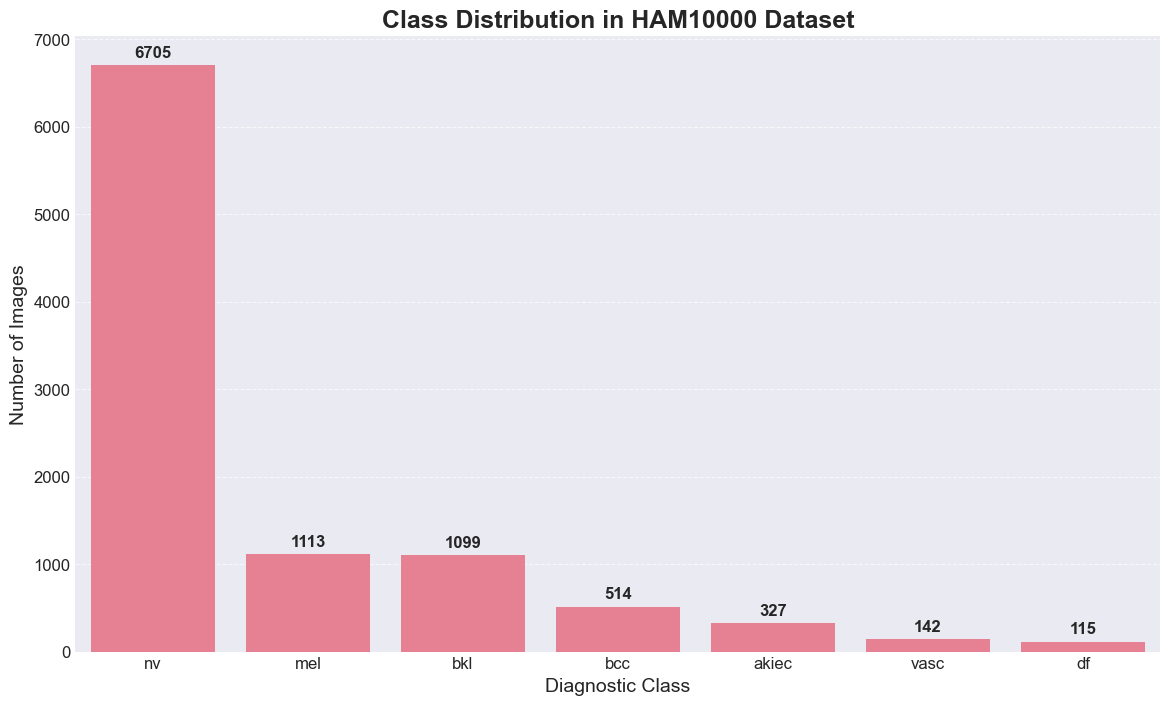

In [2]:
# =====================================================================================
# EDA FUNCTION: CLASS DISTRIBUTION
# =====================================================================================
def analyze_class_distribution(df: pd.DataFrame, target_col: str, dataset_name: str, config: MIDASConfig):
    """
    Analyzes and visualizes the class distribution for a given dataset.

    Args:
        df (pd.DataFrame): The dataframe containing the metadata.
        target_col (str): The name of the target variable column.
        dataset_name (str): The name of the dataset for logging and titles.
        config (MIDASConfig): The project configuration object.
    """
    logger.info(f"--- Analyzing Class Distribution for {dataset_name} ---")
    
    # Calculate class counts and percentages
    class_counts = df[target_col].value_counts()
    class_percentages = df[target_col].value_counts(normalize=True) * 100
    
    dist_df = pd.DataFrame({
        'Class': class_counts.index,
        'Count': class_counts.values,
        'Percentage': class_percentages.values
    })
    
    # Log the distribution
    logger.info(f"Class distribution for {dataset_name}:")
    for _, row in dist_df.iterrows():
        logger.info(f"  - {row['Class']} ({config.class_name_map.get(row['Class'].lower(), 'Unknown')}): {row['Count']} samples ({row['Percentage']:.2f}%)")

    # --- Visualization ---
    plt.figure(figsize=(14, 8))
    ax = sns.barplot(data=dist_df, x='Class', y='Count', order=dist_df.sort_values('Count', ascending=False)['Class'])
    
    # Add annotations
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=12,
                    fontweight='bold')

    plt.title(f'Class Distribution in {dataset_name} Dataset', fontsize=18, fontweight='bold')
    plt.xlabel('Diagnostic Class', fontsize=14)
    plt.ylabel('Number of Images', fontsize=14)
    plt.xticks(rotation=0, ha='center', fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Save the plot
    plot_path = config.results_dir / "plots" / f"{dataset_name}_class_distribution.png"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    logger.info(f"Class distribution plot saved to: {plot_path}")
    
    plt.show()

# =====================================================================================
# EXECUTION
# =====================================================================================
if 'ham10000' in datasets:
    ham_df = datasets['ham10000']['df']
    analyze_class_distribution(df=ham_df, target_col='dx', dataset_name="HAM10000", config=config)
else:
    logger.warning("HAM10000 dataset not found in the 'datasets' dictionary. Skipping analysis.")

INFO: --- Analyzing Metadata Features for HAM10000 ---
INFO: Analyzing missing values...
INFO: Columns with missing values:
INFO:   - 'age': 57 missing (0.57%)
INFO: Temporarily imputed missing 'age' values with median (50.0) for visualization.
INFO: Analyzing 'age' feature...
INFO: 'Age' distribution plot saved to: results\plots\HAM10000_age_distribution.png


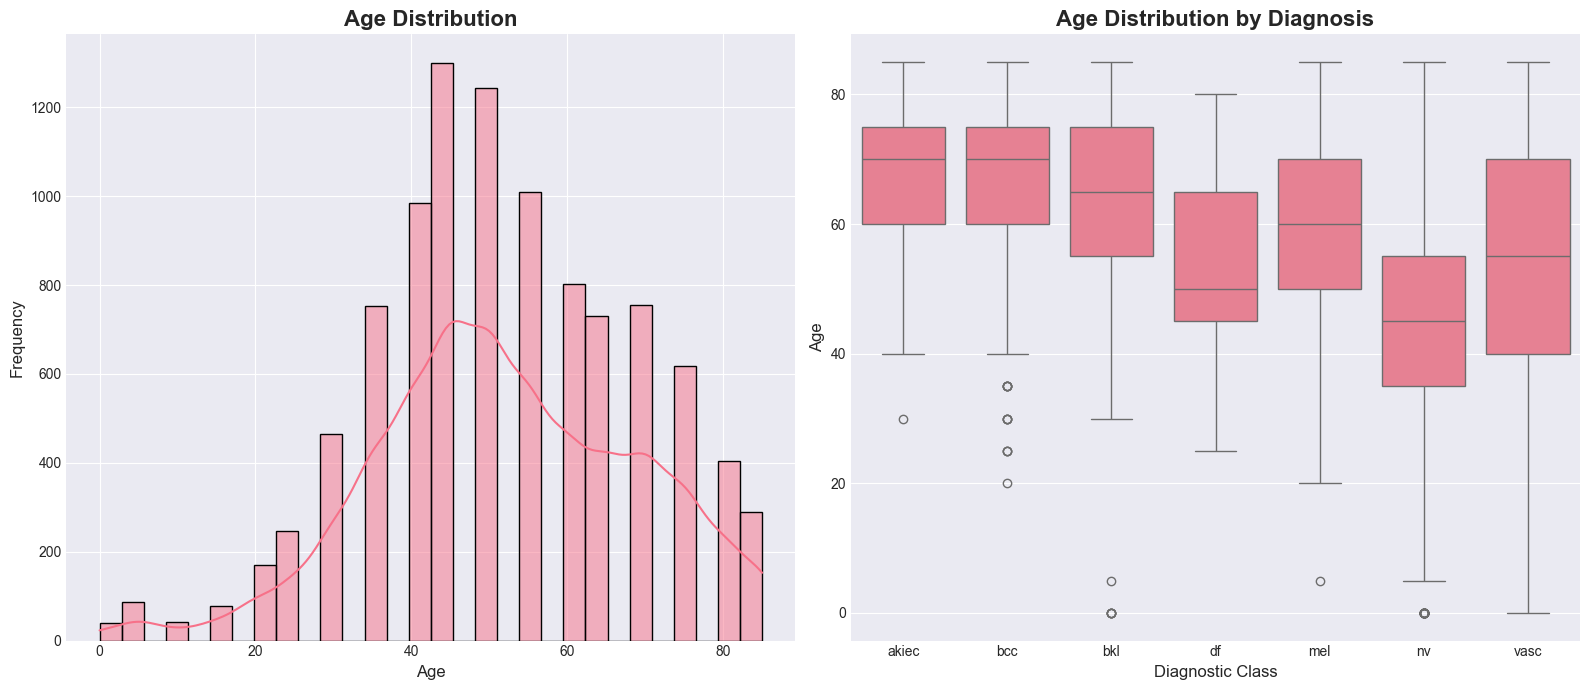

INFO: Analyzing 'sex' feature...
INFO: 'sex' distribution plot saved to: results\plots\HAM10000_sex_distribution.png


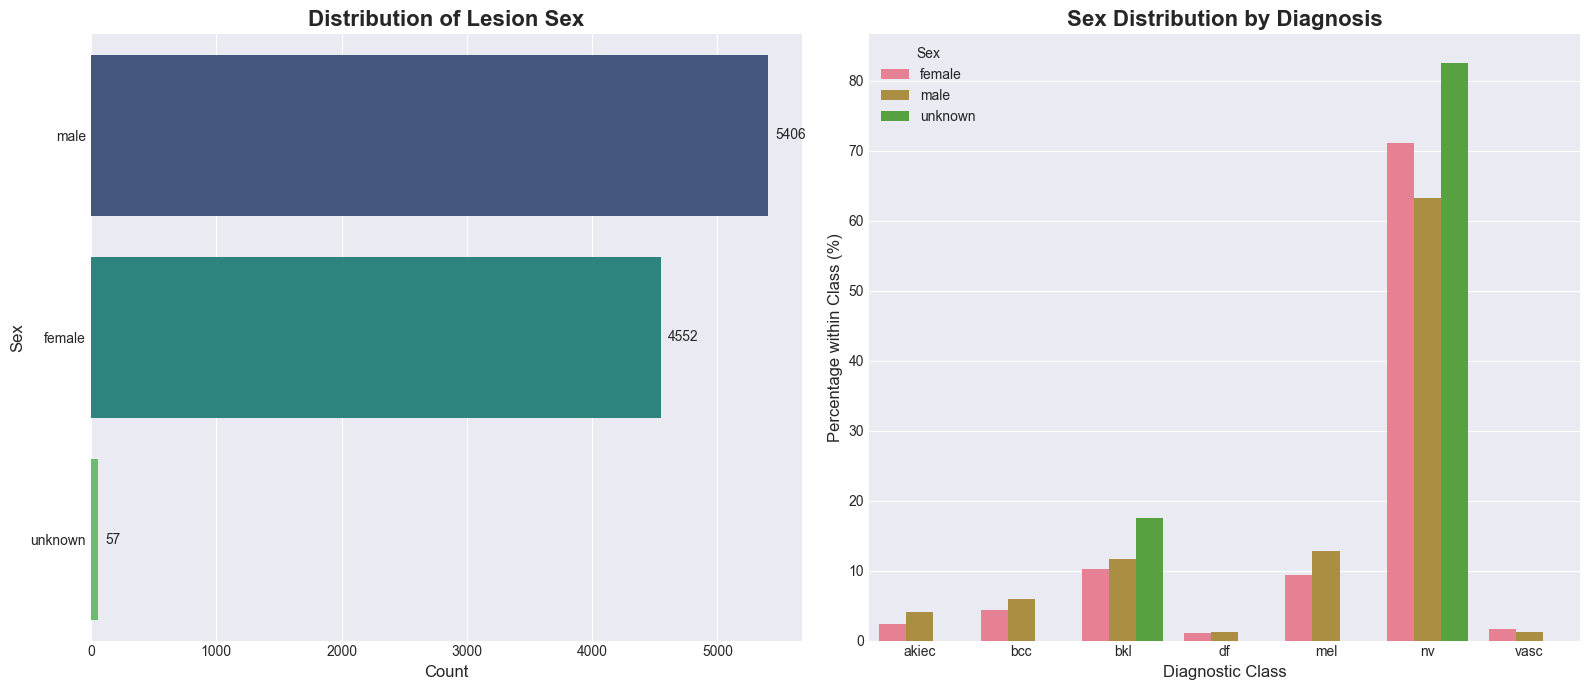

INFO: Analyzing 'localization' feature...
INFO: 'localization' distribution plot saved to: results\plots\HAM10000_localization_distribution.png


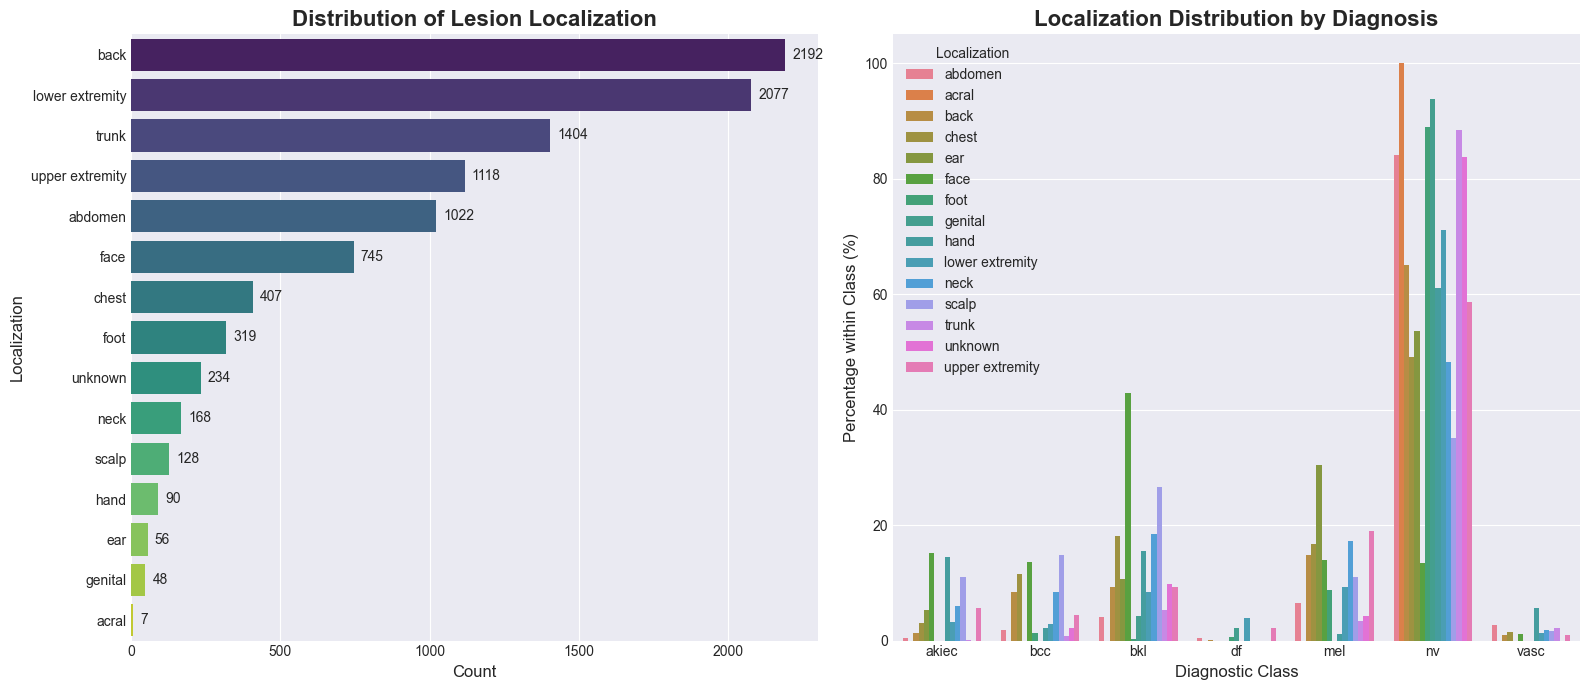

In [3]:
# =====================================================================================
# EDA FUNCTION: METADATA FEATURES
# =====================================================================================
def analyze_metadata_features(df: pd.DataFrame, dataset_name: str, config: MIDASConfig):
    """
    Performs a comprehensive analysis of metadata features (age, sex, localization).
    
    Args:
        df (pd.DataFrame): The dataframe containing the metadata.
        dataset_name (str): The name of the dataset for logging and titles.
        config (MIDASConfig): The project configuration object.
    """
    logger.info(f"--- Analyzing Metadata Features for {dataset_name} ---")
    
    # 1. Missing Value Analysis
    logger.info("Analyzing missing values...")
    missing_data = df.isnull().sum()
    missing_data = missing_data[missing_data > 0]
    if not missing_data.empty:
        logger.info("Columns with missing values:")
        for col, count in missing_data.items():
            logger.info(f"  - '{col}': {count} missing ({count/len(df)*100:.2f}%)")
    else:
        logger.info("No missing values found in metadata.")

    # Create a copy to avoid SettingWithCopyWarning
    df_copy = df.copy()

    # Impute age for visualization purposes only. We will use a more robust strategy later.
    if 'age' in df_copy.columns and df_copy['age'].isnull().any():
        median_age = df_copy['age'].median()
        df_copy['age'].fillna(median_age, inplace=True)
        logger.info(f"Temporarily imputed missing 'age' values with median ({median_age}) for visualization.")
        
    # Define the correct order using the lowercase keys from the config map
    dx_order = list(config.class_name_map.keys())

    # 2. Numerical Feature Analysis: Age
    if 'age' in df_copy.columns:
        logger.info("Analyzing 'age' feature...")
        plt.figure(figsize=(16, 7))
        
        # Histogram of Age
        plt.subplot(1, 2, 1)
        sns.histplot(df_copy['age'], bins=30, kde=True)
        plt.title('Age Distribution', fontsize=16, fontweight='bold')
        plt.xlabel('Age', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        
        # Boxplot of Age by Diagnosis
        plt.subplot(1, 2, 2)
        # CORRECTED: Use the lowercase dx_order list for ordering
        sns.boxplot(x='dx', y='age', data=df_copy, order=dx_order)
        plt.title('Age Distribution by Diagnosis', fontsize=16, fontweight='bold')
        plt.xlabel('Diagnostic Class', fontsize=12)
        plt.ylabel('Age', fontsize=12)
        plt.tight_layout()

        plot_path = config.results_dir / "plots" / f"{dataset_name}_age_distribution.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        logger.info(f"'Age' distribution plot saved to: {plot_path}")
        plt.show()

    # 3. Categorical Feature Analysis
    categorical_features = ['sex', 'localization']
    for feature in categorical_features:
        if feature in df.columns:
            logger.info(f"Analyzing '{feature}' feature...")
            plt.figure(figsize=(16, 7))
            
            # Count Plot for the feature
            plt.subplot(1, 2, 1)
            ax1 = sns.countplot(y=feature, data=df, order=df[feature].value_counts().index, palette='viridis')
            plt.title(f'Distribution of Lesion {feature.capitalize()}', fontsize=16, fontweight='bold')
            plt.xlabel('Count', fontsize=12)
            plt.ylabel(feature.capitalize(), fontsize=12)
            for p in ax1.patches:
                ax1.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                             ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

            # Distribution of the feature by Diagnosis
            plt.subplot(1, 2, 2)
            df_grouped = df.groupby(feature)['dx'].value_counts(normalize=True).mul(100).rename('percent').reset_index()
            # CORRECTED: Use the lowercase dx_order list for ordering
            sns.barplot(x='dx', y='percent', hue=feature, data=df_grouped, order=dx_order)
            plt.title(f'{feature.capitalize()} Distribution by Diagnosis', fontsize=16, fontweight='bold')
            plt.xlabel('Diagnostic Class', fontsize=12)
            plt.ylabel('Percentage within Class (%)', fontsize=12)
            plt.legend(title=feature.capitalize())
            plt.tight_layout()
            
            plot_path = config.results_dir / "plots" / f"{dataset_name}_{feature}_distribution.png"
            plt.savefig(plot_path, dpi=300, bbox_inches='tight')
            logger.info(f"'{feature}' distribution plot saved to: {plot_path}")
            plt.show()

# =====================================================================================
# EXECUTION
# =====================================================================================
if 'ham10000' in datasets:
    ham_df = datasets['ham10000']['df']
    analyze_metadata_features(df=ham_df, dataset_name="HAM10000", config=config)
else:
    logger.warning("HAM10000 dataset not found in the 'datasets' dictionary. Skipping analysis.")

In [4]:
# =====================================================================================
# PREPROCESSING FUNCTION
# =====================================================================================
def preprocess_ham10000_data(df: pd.DataFrame, config: MIDASConfig) -> Optional[pd.DataFrame]:
    """
    Applies all preprocessing steps to the HAM10000 dataframe.

    Args:
        df (pd.DataFrame): The raw HAM10000 dataframe.
        config (MIDASConfig): The project configuration object.

    Returns:
        Optional[pd.DataFrame]: The preprocessed dataframe, or None if input is invalid.
    """
    if df is None:
        logger.error("Input DataFrame is None. Cannot preprocess.")
        return None
        
    logger.info("--- Starting Preprocessing for HAM10000 ---")
    
    processed_df = df.copy()

    if processed_df['age'].isnull().any():
        median_age = processed_df['age'].median()
        processed_df['age'].fillna(median_age, inplace=True)
        logger.info(f"Imputed {df['age'].isnull().sum()} missing 'age' values with median: {median_age}")
    
    if 'sex' in processed_df.columns:
        processed_df['sex'] = processed_df['sex'].astype('category')
        
    if 'localization' in processed_df.columns:
        processed_df['localization'] = processed_df['localization'].astype('category')

    try:
        processed_df['image_path'] = processed_df['image_id'].apply(
            lambda x: config.ham10000_images / f"{x}.jpg"
        )
        if not processed_df['image_path'].iloc[0].exists():
            logger.warning(f"Sample image path does not exist: {processed_df['image_path'].iloc[0]}")
            logger.warning("Please ensure your data directory structure is correct.")
        else:
             logger.info("Created 'image_path' column successfully.")
    except Exception as e:
        logger.error(f"Failed to create image paths. Error: {e}")
        return None

    dx_to_label_map = {label: i for i, label in enumerate(config.class_name_map.keys())}
    processed_df['label'] = processed_df['dx'].map(dx_to_label_map)
    logger.info("Encoded target variable 'dx' into 'label' column.")
    
    logger.info("Class to Label mapping:")
    for key, value in dx_to_label_map.items():
        logger.info(f"  - '{key}': {value}")
        
    if processed_df.isnull().sum().sum() > 0:
        logger.warning("There are still missing values after preprocessing. Please investigate.")
    else:
        logger.info("Preprocessing complete. No missing values remain in the processed DataFrame.")

    return processed_df

# =====================================================================================
# EXECUTION
# =====================================================================================
if 'ham10000' in datasets:
    processed_ham_df = preprocess_ham10000_data(df=datasets['ham10000']['df'], config=config)
    
    if processed_ham_df is not None:
        logger.info("--- Verification of Preprocessed DataFrame ---")
        
        print("\nDataFrame Head:")
        print(processed_ham_df.head())
        
        print("\nDataFrame Info:")
        processed_ham_df.info()
else:
    logger.warning("HAM10000 dataset not found in the 'datasets' dictionary. Skipping preprocessing.")

INFO: --- Starting Preprocessing for HAM10000 ---
INFO: Imputed 57 missing 'age' values with median: 50.0
INFO: Created 'image_path' column successfully.
INFO: Encoded target variable 'dx' into 'label' column.
INFO: Class to Label mapping:
INFO:   - 'akiec': 0
INFO:   - 'bcc': 1
INFO:   - 'bkl': 2
INFO:   - 'df': 3
INFO:   - 'mel': 4
INFO:   - 'nv': 5
INFO:   - 'vasc': 6
INFO: Preprocessing complete. No missing values remain in the processed DataFrame.
INFO: --- Verification of Preprocessed DataFrame ---

DataFrame Head:
     lesion_id      image_id   dx dx_type   age   sex localization  \
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp   
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp   
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp   
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp   
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear   

                              image_path  label  
0 

In [5]:
# =====================================================================================
# DATA SPLITTING FUNCTION
# =====================================================================================
def split_data_lesion_level(df: pd.DataFrame, config: MIDASConfig) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Splits the dataframe on a lesion level to prevent data leakage, using stratification.

    Args:
        df (pd.DataFrame): The preprocessed dataframe.
        config (MIDASConfig): The project configuration object.

    Returns:
        A tuple containing the training, validation, and test dataframes.
    """
    logger.info("--- Splitting Data on Lesion Level (70/15/15) ---")

    # Create a dataframe of unique lesions and their corresponding labels
    lesion_df = df.drop_duplicates('lesion_id').set_index('lesion_id')
    
    # Get lesion IDs and their corresponding labels for stratification
    lesion_ids = lesion_df.index.values
    lesion_labels = lesion_df['label'].values
    
    # First split: 70% train, 30% temp (validation + test)
    train_lesion_ids, temp_lesion_ids, _, _ = train_test_split(
        lesion_ids, lesion_labels,
        test_size=0.30,
        random_state=config.seed,
        stratify=lesion_labels
    )

    # Get the labels for the temporary set for the second split
    temp_labels = lesion_df.loc[temp_lesion_ids]['label'].values
    
    # Second split: 50% of temp for validation, 50% for test (results in 15% of total for each)
    val_lesion_ids, test_lesion_ids, _, _ = train_test_split(
        temp_lesion_ids, temp_labels,
        test_size=0.50,
        random_state=config.seed,
        stratify=temp_labels
    )
    
    # Create the final dataframes by filtering the original dataframe
    train_df = df[df['lesion_id'].isin(train_lesion_ids)].copy()
    val_df = df[df['lesion_id'].isin(val_lesion_ids)].copy()
    test_df = df[df['lesion_id'].isin(test_lesion_ids)].copy()

    # --- Verification Logging ---
    logger.info(f"Total samples: {len(df)}")
    logger.info(f"Training set: {len(train_df)} samples ({len(train_df)/len(df)*100:.2f}%)")
    logger.info(f"Validation set: {len(val_df)} samples ({len(val_df)/len(df)*100:.2f}%)")
    logger.info(f"Test set: {len(test_df)} samples ({len(test_df)/len(df)*100:.2f}%)")
    
    for split_name, split_df in [('Training', train_df), ('Validation', val_df), ('Test', test_df)]:
        dist = split_df['dx'].value_counts(normalize=True).sort_index()
        logger.info(f"Class distribution in {split_name} set:")
        for dx_class, percentage in dist.items():
            logger.info(f"  - {dx_class}: {percentage:.2%}")
            
    return train_df, val_df, test_df

# =====================================================================================
# EXECUTION
# =====================================================================================
if 'processed_ham_df' in locals() and processed_ham_df is not None:
    train_df, val_df, test_df = split_data_lesion_level(df=processed_ham_df, config=config)
else:
    logger.error("Preprocessed dataframe not found. Cannot perform split.")

INFO: --- Splitting Data on Lesion Level (70/15/15) ---
INFO: Total samples: 10015
INFO: Training set: 7002 samples (69.92%)
INFO: Validation set: 1532 samples (15.30%)
INFO: Test set: 1481 samples (14.79%)
INFO: Class distribution in Training set:
INFO:   - akiec: 3.28%
INFO:   - bcc: 5.23%
INFO:   - bkl: 11.05%
INFO:   - df: 1.09%
INFO:   - mel: 11.11%
INFO:   - nv: 66.82%
INFO:   - vasc: 1.41%
INFO: Class distribution in Validation set:
INFO:   - akiec: 3.33%
INFO:   - bcc: 5.03%
INFO:   - bkl: 10.25%
INFO:   - df: 1.24%
INFO:   - mel: 11.10%
INFO:   - nv: 67.49%
INFO:   - vasc: 1.57%
INFO: Class distribution in Test set:
INFO:   - akiec: 3.11%
INFO:   - bcc: 4.79%
INFO:   - bkl: 11.34%
INFO:   - df: 1.35%
INFO:   - mel: 11.14%
INFO:   - nv: 66.98%
INFO:   - vasc: 1.28%


In [6]:
# =====================================================================================
# METADATA FINAL PREPARATION
# =====================================================================================
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from typing import List

def finalize_metadata(
    train_df: pd.DataFrame, 
    val_df: pd.DataFrame, 
    test_df: pd.DataFrame
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, List[str]]:
    """
    Applies final scaling and encoding to metadata features.

    Args:
        train_df, val_df, test_df: The data splits.

    Returns:
        A tuple of the updated dataframes and the final list of metadata feature names.
    """
    logger.info("--- Finalizing Metadata (Scaling & One-Hot Encoding) ---")
    
    numerical_cols = ['age']
    categorical_cols = ['sex', 'localization']

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
        ],
        remainder='drop'
    )
    
    logger.info("Fitting preprocessor on training data...")
    preprocessor.fit(train_df)
    
    try:
        ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
        final_feature_names = numerical_cols + ohe_feature_names.tolist()
    except AttributeError:
        cats = preprocessor.named_transformers_['cat'].categories_
        ohe_feature_names = [
            f"{col}_{cat}" for col, cat_list in zip(categorical_cols, cats) for cat in cat_list[1:]
        ]
        final_feature_names = numerical_cols + ohe_feature_names

    logger.info(f"Preprocessor fitted. Total metadata features: {len(final_feature_names)}")

    logger.info("Transforming train, validation, and test sets...")
    X_train_meta = preprocessor.transform(train_df).toarray()
    X_val_meta = preprocessor.transform(val_df).toarray()
    X_test_meta = preprocessor.transform(test_df).toarray()
    
    train_df['metadata_features'] = list(X_train_meta)
    val_df['metadata_features'] = list(X_val_meta)
    test_df['metadata_features'] = list(X_test_meta)

    logger.info("Successfully added 'metadata_features' to dataframes.")
    logger.info(f"Sample metadata vector (first training sample): {X_train_meta[0]}")
    
    return train_df, val_df, test_df, final_feature_names

# =====================================================================================
# EXECUTION
# =====================================================================================
if 'train_df' in locals():
    train_df, val_df, test_df, metadata_feature_names = finalize_metadata(train_df, val_df, test_df)
    config.num_metadata_features = len(metadata_feature_names)
else:
    logger.error("Training dataframe not found. Cannot finalize metadata.")

INFO: --- Finalizing Metadata (Scaling & One-Hot Encoding) ---
INFO: Fitting preprocessor on training data...
INFO: Preprocessor fitted. Total metadata features: 17
INFO: Transforming train, validation, and test sets...
INFO: Successfully added 'metadata_features' to dataframes.
INFO: Sample metadata vector (first training sample): [1.67698371 1.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         1.         0.         0.         0.        ]


INFO: Train dataset size: 7002
INFO: Validation dataset size: 1532
INFO: Test dataset size: 1481
INFO: DataLoaders created. Batch size: 32
INFO: Verifying DataLoader and visualizing a sample batch...
INFO: DataLoader verification plot saved to: results\plots\dataloader_verification_batch.png


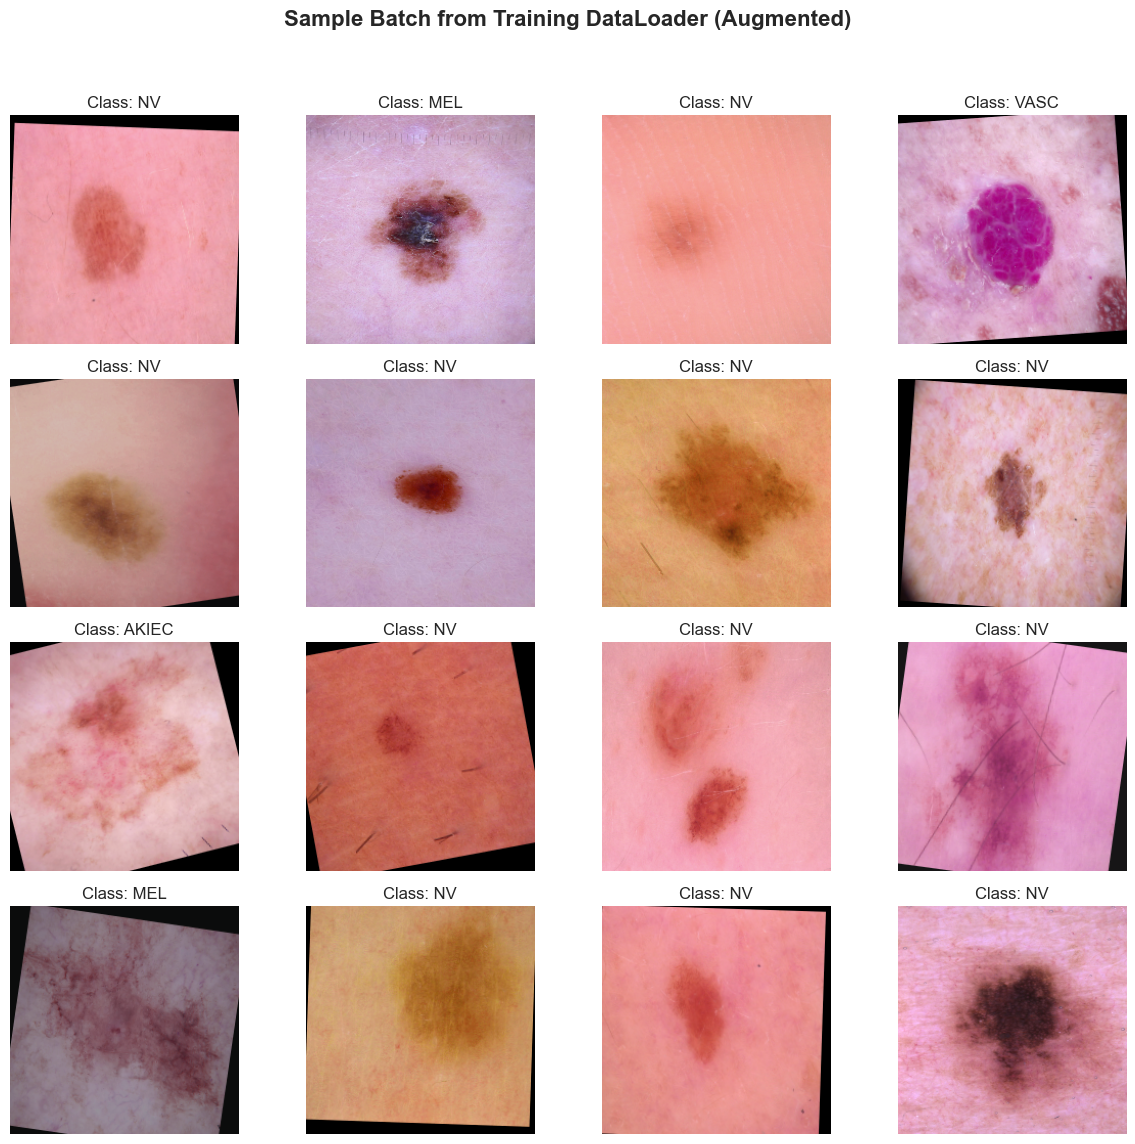

In [7]:
# =====================================================================================
# PYTORCH DATASET AND TRANSFORMS
# =====================================================================================
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torchvision.transforms as transforms

def get_transforms(is_train: bool, img_size: int) -> A.Compose:
    """
    Returns the augmentation pipeline for images.
    
    Args:
        is_train (bool): If True, returns the training augmentations, else validation/test augmentations.
        img_size (int): The target image size.

    Returns:
        A.Compose: The Albumentations transformation pipeline.
    """
    if is_train:
        transform = A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])
    else:
        transform = A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])
    return transform

class MIDASDataset(Dataset):
    """Custom PyTorch Dataset for the MIDAS project."""
    def __init__(self, df: pd.DataFrame, transform: A.Compose = None):
        self.df = df
        self.image_paths = df['image_path'].values
        self.metadata_features = df['metadata_features'].values
        self.labels = df['label'].values
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, index: int) -> Dict[str, torch.Tensor]:
        image_path = str(self.image_paths[index])
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            image = self.transform(image=image)['image']
        
        metadata = torch.tensor(self.metadata_features[index], dtype=torch.float)
        label = torch.tensor(self.labels[index], dtype=torch.long)
        
        return {'image': image, 'metadata': metadata, 'label': label}

def verify_dataloader(loader: DataLoader, config: MIDASConfig):
    """Fetches and visualizes a single batch from a DataLoader."""
    logger.info("Verifying DataLoader and visualizing a sample batch...")
    
    batch = next(iter(loader))
    images, labels = batch['image'], batch['label']
    
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    fig.suptitle('Sample Batch from Training DataLoader (Augmented)', fontsize=16, fontweight='bold')
    
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    unnormalize = transforms.Normalize((-mean / std).tolist(), (1.0 / std).tolist())

    label_to_dx = {i: dx for i, dx in enumerate(list(config.class_name_map.keys()))}
    
    for i, ax in enumerate(axes.flat):
        if i >= len(images):
            ax.axis('off')
            continue
            
        img = unnormalize(images[i])
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        label_idx = labels[i].item()
        dx_class = label_to_dx.get(label_idx, 'Unknown').upper()

        ax.imshow(img)
        ax.set_title(f"Class: {dx_class}")
        ax.axis('off')
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plot_path = config.results_dir / "plots" / "dataloader_verification_batch.png"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    logger.info(f"DataLoader verification plot saved to: {plot_path}")
    plt.show()


# =====================================================================================
# EXECUTION
# =====================================================================================
config.img_size = 224
config.batch_size = 32
config.num_workers = 0

train_dataset = MIDASDataset(train_df, transform=get_transforms(is_train=True, img_size=config.img_size))
val_dataset = MIDASDataset(val_df, transform=get_transforms(is_train=False, img_size=config.img_size))
test_dataset = MIDASDataset(test_df, transform=get_transforms(is_train=False, img_size=config.img_size))

logger.info(f"Train dataset size: {len(train_dataset)}")
logger.info(f"Validation dataset size: {len(val_dataset)}")
logger.info(f"Test dataset size: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, num_workers=config.num_workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, pin_memory=True)

logger.info(f"DataLoaders created. Batch size: {config.batch_size}")

if 'train_loader' in locals():
    verify_dataloader(train_loader, config)

In [8]:
# =====================================================================================
# MODEL ARCHITECTURE
# =====================================================================================
class MIDAS_V1(nn.Module):
    """
    Defines the Multi-Modal Intelligent Dermoscopy Analysis System (MIDAS) V1 architecture.
    """
    def __init__(self, config: MIDASConfig, pretrained: bool = True):
        super().__init__()
        self.config = config
        
        # --- Image Encoder Branch ---
        self.image_encoder = timm.create_model(
            'efficientnet_b0', 
            pretrained=pretrained, 
            num_classes=0
        )
        num_image_features = self.image_encoder.num_features
        logger.info(f"Image Encoder (EfficientNet-B0) loaded. Feature size: {num_image_features}")

        # --- Metadata Encoder Branch ---
        metadata_layers = [
            nn.Linear(self.config.num_metadata_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2)
        ]
        self.metadata_encoder = nn.Sequential(*metadata_layers)
        num_metadata_features_out = 128
        logger.info(f"Metadata Encoder (MLP) created. Input features: {self.config.num_metadata_features}, Output features: {num_metadata_features_out}")
        
        # --- Fusion and Classification Head ---
        total_features = num_image_features + num_metadata_features_out
        self.classifier = nn.Sequential(
            nn.Linear(total_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, self.config.num_classes)
        )
        logger.info(f"Classifier head created. Input features: {total_features}, Output classes: {self.config.num_classes}")

    def forward(self, image: torch.Tensor, metadata: torch.Tensor) -> torch.Tensor:
        image_features = self.image_encoder(image)
        metadata_features = self.metadata_encoder(metadata)
        
        fused_features = torch.cat([image_features, metadata_features], dim=1)
        
        output = self.classifier(fused_features)
        
        return output

# =====================================================================================
# EXECUTION AND VERIFICATION
# =====================================================================================
def verify_model_forward_pass(model: nn.Module, loader: DataLoader, device: torch.device):
    """Performs a single forward pass to verify the model architecture."""
    logger.info("--- Verifying model architecture with a single forward pass ---")
    
    try:
        model.to(device)
        model.eval()
        
        batch = next(iter(loader))
        images = batch['image'].to(device)
        metadata = batch['metadata'].to(device)
        
        logger.info(f"Input image batch shape: {images.shape}")
        logger.info(f"Input metadata batch shape: {metadata.shape}")
        
        with torch.no_grad():
            output = model(images, metadata)
            
        logger.info(f"SUCCESS: Forward pass complete.")
        logger.info(f"Output tensor shape: {output.shape}")
        
        expected_shape = (config.batch_size, config.num_classes)
        assert output.shape == expected_shape, f"Shape mismatch! Expected {expected_shape}, but got {output.shape}"
        logger.info(f"Output shape matches expected shape: {expected_shape}")

    except Exception as e:
        logger.error(f"Model verification failed. Error: {e}", exc_info=True)

midas_model = MIDAS_V1(config=config)
verify_model_forward_pass(model=midas_model, loader=train_loader, device=device)

INFO: Image Encoder (EfficientNet-B0) loaded. Feature size: 1280
INFO: Metadata Encoder (MLP) created. Input features: 17, Output features: 128
INFO: Classifier head created. Input features: 1408, Output classes: 7
INFO: --- Verifying model architecture with a single forward pass ---
INFO: Input image batch shape: torch.Size([32, 3, 224, 224])
INFO: Input metadata batch shape: torch.Size([32, 17])
INFO: SUCCESS: Forward pass complete.
INFO: Output tensor shape: torch.Size([32, 7])
INFO: Output shape matches expected shape: (32, 7)


In [9]:
# =====================================================================================
# LOSS FUNCTION
# =====================================================================================
from torch.cuda.amp import autocast, GradScaler
import torch.optim as optim
from sklearn.utils import class_weight
from torchmetrics import Accuracy, F1Score, AUROC, CohenKappa

class WeightedFocalLoss(nn.Module):
    "Non-native implementation of focal loss, with class weights."
    def __init__(self, alpha: torch.Tensor, gamma: float = 2.0):
        super(WeightedFocalLoss, self).__init__()
        self.alpha = alpha.to(device)
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = nn.functional.cross_entropy(inputs, targets, reduction='none')
        targets = targets.type(torch.long)
        at = self.alpha.gather(0, targets.data.view(-1))
        pt = torch.exp(-BCE_loss)
        F_loss = at * (1 - pt)**self.gamma * BCE_loss
        return F_loss.mean()

# =====================================================================================
# TRAINING AND EVALUATION FUNCTIONS
# =====================================================================================
def train_one_epoch(model, loader, optimizer, loss_fn, scaler):
    model.train()
    total_loss = 0.0
    progress_bar = tqdm(loader, desc="Training", leave=False)
    
    for batch in progress_bar:
        images = batch['image'].to(device)
        metadata = batch['metadata'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        
        with autocast():
            outputs = model(images, metadata)
            loss = loss_fn(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())
        
    return total_loss / len(loader)

def evaluate(model, loader, loss_fn, config):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        progress_bar = tqdm(loader, desc="Evaluating", leave=False)
        for batch in progress_bar:
            images = batch['image'].to(device)
            metadata = batch['metadata'].to(device)
            labels = batch['label'].to(device)
            
            with autocast():
                outputs = model(images, metadata)
                loss = loss_fn(outputs, labels)

            total_loss += loss.item()
            all_preds.append(outputs.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    # --- Calculate Metrics ---
    metrics = {}
    metric_device = 'cpu'
    accuracy = Accuracy(task="multiclass", num_classes=config.num_classes).to(metric_device)
    bal_accuracy = Accuracy(task="multiclass", num_classes=config.num_classes, average='macro').to(metric_device)
    f1 = F1Score(task="multiclass", num_classes=config.num_classes, average='macro').to(metric_device)
    auroc = AUROC(task="multiclass", num_classes=config.num_classes).to(metric_device)
    
    metrics['loss'] = total_loss / len(loader)
    metrics['accuracy'] = accuracy(all_preds, all_labels).item()
    metrics['balanced_accuracy'] = bal_accuracy(all_preds, all_labels).item()
    metrics['f1_macro'] = f1(all_preds, all_labels).item()
    metrics['auroc'] = auroc(all_preds.softmax(dim=-1), all_labels).item()

    return metrics

def run_training(model, train_loader, val_loader, config):
    
    # --- Optimizer ---
    optimizer = optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
    
    # --- LR Scheduler ---
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.num_epochs, eta_min=1e-6)
    
    # --- Loss Function ---
    class_weights = class_weight.compute_class_weight(
        'balanced',
        classes=np.unique(train_loader.dataset.labels),
        y=train_loader.dataset.labels
    )
    loss_fn = WeightedFocalLoss(alpha=torch.tensor(class_weights, dtype=torch.float32))
    logger.info(f"Using WeightedFocalLoss with weights: {np.round(class_weights, 2)}")

    # --- Training Utilities ---
    scaler = GradScaler()
    best_val_metric = 0
    epochs_no_improve = 0
    
    logger.info("--- Starting Model Training ---")
    
    for epoch in range(config.num_epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, scaler)
        val_metrics = evaluate(model, val_loader, loss_fn, config)
        scheduler.step()
        
        logger.info(
            f"Epoch {epoch+1}/{config.num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Bal Acc: {val_metrics['balanced_accuracy']:.4f} | "
            f"Val AUROC: {val_metrics['auroc']:.4f}"
        )
        
        # --- Checkpointing and Early Stopping ---
        current_val_metric = val_metrics[config.early_stopping_metric]
        if current_val_metric > best_val_metric:
            best_val_metric = current_val_metric
            epochs_no_improve = 0
            save_path = config.models_dir / "checkpoints" / "midas_v1_best.pth"
            torch.save(model.state_dict(), save_path)
            logger.info(f"Validation metric improved. Saving model to {save_path}")
        else:
            epochs_no_improve += 1
        
        if epochs_no_improve >= config.patience:
            logger.info(f"Early stopping triggered after {config.patience} epochs with no improvement.")
            break
            
    logger.info("--- Model Training Finished ---")
    return model

# =====================================================================================
# EXECUTION
# =====================================================================================
# Add training parameters to config
config.num_epochs = 50
config.learning_rate = 1e-4
config.weight_decay = 1e-5
config.patience = 10
config.early_stopping_metric = 'balanced_accuracy'

# Run the training loop
midas_model.to(device)
trained_model = run_training(midas_model, train_loader, val_loader, config)

INFO: Using WeightedFocalLoss with weights: [ 4.35  2.73  1.29 13.16  1.29  0.21 10.1 ]
INFO: --- Starting Model Training ---


Training:   0%|          | 0/219 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

INFO: Epoch 1/50 | Train Loss: 0.9716 | Val Loss: 0.5698 | Val Bal Acc: 0.6260 | Val AUROC: 0.9112
INFO: Validation metric improved. Saving model to models\checkpoints\midas_v1_best.pth


Training:   0%|          | 0/219 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

INFO: Epoch 13/50 | Train Loss: 0.1138 | Val Loss: 0.5902 | Val Bal Acc: 0.6775 | Val AUROC: 0.9475


Training:   0%|          | 0/219 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

INFO: Epoch 14/50 | Train Loss: 0.1008 | Val Loss: 0.5231 | Val Bal Acc: 0.7165 | Val AUROC: 0.9507
INFO: Early stopping triggered after 10 epochs with no improvement.
INFO: --- Model Training Finished ---


INFO: --- Final Evaluation on Test Set ---
INFO: Loaded best model weights from: models\checkpoints\midas_v1_best.pth


Testing:   0%|          | 0/47 [00:00<?, ?it/s]

INFO: Classification Report on Test Set:
              precision    recall  f1-score   support

       akiec       0.33      0.72      0.45        46
         bcc       0.58      0.69      0.63        71
         bkl       0.49      0.61      0.54       168
          df       0.35      0.90      0.50        20
         mel       0.39      0.56      0.46       165
          nv       0.98      0.76      0.85       992
        vasc       0.52      0.84      0.64        19

    accuracy                           0.72      1481
   macro avg       0.52      0.72      0.58      1481
weighted avg       0.80      0.72      0.74      1481

INFO: Confusion matrix plot saved to: results\plots\test_confusion_matrix.png


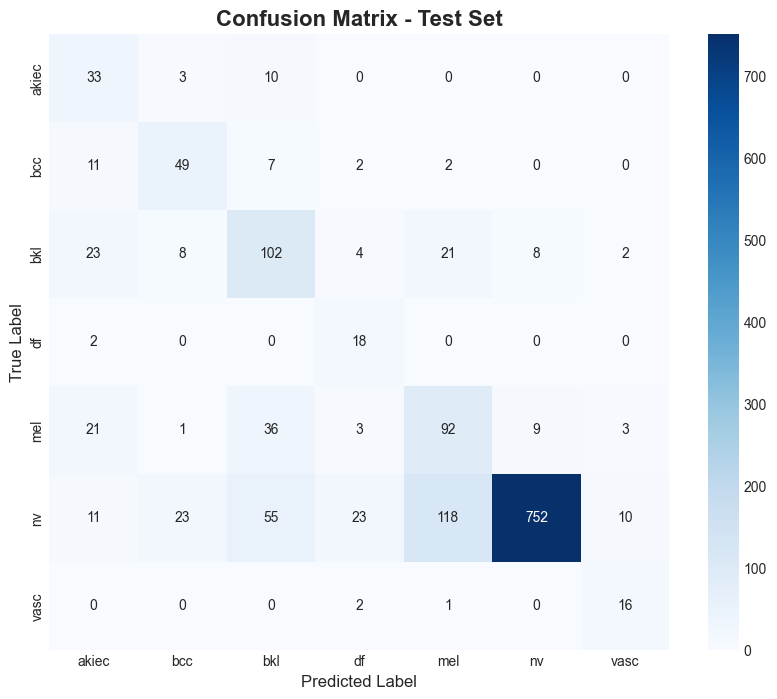

In [10]:
# =====================================================================================
# FINAL MODEL EVALUATION
# =====================================================================================
from sklearn.metrics import classification_report, confusion_matrix

def test_model(model, test_loader, config):
    """
    Evaluates the final model on the test set.

    Args:
        model (nn.Module): The model architecture.
        test_loader (DataLoader): The DataLoader for the test set.
        config (MIDASConfig): The project configuration object.
    """
    logger.info("--- Final Evaluation on Test Set ---")
    
    # --- Load Best Model Weights ---
    model_path = config.models_dir / "checkpoints" / "midas_v1_best.pth"
    if model_path.exists():
        model.load_state_dict(torch.load(model_path))
        logger.info(f"Loaded best model weights from: {model_path}")
    else:
        logger.error(f"Best model checkpoint not found at {model_path}. Evaluation will use the model's current weights.")

    model.to(device)
    model.eval()
    
    # --- Get Predictions ---
    all_preds = []
    all_labels = []
    with torch.no_grad():
        progress_bar = tqdm(test_loader, desc="Testing", leave=False)
        for batch in progress_bar:
            images = batch['image'].to(device)
            metadata = batch['metadata'].to(device)
            labels = batch['label'].to(device)
            
            with autocast():
                outputs = model(images, metadata)

            all_preds.append(outputs.cpu())
            all_labels.append(labels.cpu())

    all_preds_tensor = torch.cat(all_preds)
    all_labels_tensor = torch.cat(all_labels)
    
    # Get final predicted classes
    final_preds = all_preds_tensor.argmax(dim=1)

    # --- Log Classification Report ---
    class_names = list(config.class_name_map.keys())
    report = classification_report(all_labels_tensor, final_preds, target_names=class_names)
    logger.info("Classification Report on Test Set:\n" + report)
    
    # --- Generate and Plot Confusion Matrix ---
    cm = confusion_matrix(all_labels_tensor, final_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    
    cm_plot_path = config.results_dir / "plots" / "test_confusion_matrix.png"
    plt.savefig(cm_plot_path, dpi=300, bbox_inches='tight')
    logger.info(f"Confusion matrix plot saved to: {cm_plot_path}")
    plt.show()

# =====================================================================================
# EXECUTION
# =====================================================================================
if 'midas_model' in locals() and 'test_loader' in locals():
    test_model(midas_model, test_loader, config)
else:
    logger.error("Model or test_loader not found. Cannot perform final evaluation.")